Road Damage Detection and Maintenance Priority System

Name: Suvrajit Senapati

Program: B.Tech (Computer Science & Engineering)

University: C.V. Raman Global University

Project Description:
This project demonstrates an AI-based system that detects road damage from images using computer vision techniques. The system analyzes road images, identifies potential damage, and calculates a maintenance priority score based on severity and traffic conditions.

# Road Damage Detection and Maintenance Priority System

1. This project uses computer vision and deep learning to identify road damage
such as potholes and cracks.
2. A YOLOv8 model is used for object detection. The detected damage is further evaluated using a severity scoring mechanism.
3. Based on severity, traffic volume, and repair cost, a maintenance priority score is calculated to help authorities schedule repairs efficiently.

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 8.2 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model = YOLO("yolov8n.pt")  # Pretrained model

results = model("https://ultralytics.com/images/bus.jpg", save=True)


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 564.0ms
Speed: 32.2ms preprocess, 564.0ms inference, 42.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


In [5]:
import zipfile

zip_path = "/content/Road issue detection.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [6]:
import os
os.listdir("/content/dataset")

['data']

In [7]:
import os
os.listdir("/content/dataset/data")

['Road Issues', 'Public Cleanliness + Environmental Issues']

In [8]:
import os
os.listdir("/content/dataset/data/Road Issues")[:10]

['Broken Road Sign Issues',
 'Illegal Parking Issues',
 'Pothole Issues',
 'Mixed Issues',
 'Damaged Road issues']

In [9]:
import os

os.listdir("/content/dataset/data/Road Issues/Pothole Issues")[:10]

['321_jpg.rf.750ee4f1efbc474e897c8110a3bcb7bb.jpg',
 '398_jpg.rf.7ee3e911fa99869b5f3b7c1ea7b34361.jpg',
 '208_jpg.rf.671350932b22f8229a5ec4a61f490594.jpg',
 '422_jpg.rf.6dba193e4248a343fc703eabdcdbfe54.jpg',
 '201_jpg.rf.28aec1ce09c8d1fc954e45c3d54fe40c.jpg',
 '154_jpg.rf.743538c84cb3ddde91f13a4a9469b48f.jpg',
 '193_jpg.rf.ea82429e9a27ba779de371ca77789940.jpg',
 '25_jpg.rf.d81777040ec12707eb5ade641cea0b79.jpg',
 '333_jpg.rf.1c84cc7aa5e4d6b53a18c7a6ee350757.jpg',
 '441_jpg.rf.9e3d3ed53bcbf9f83c7ec9612214ee60.jpg']

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

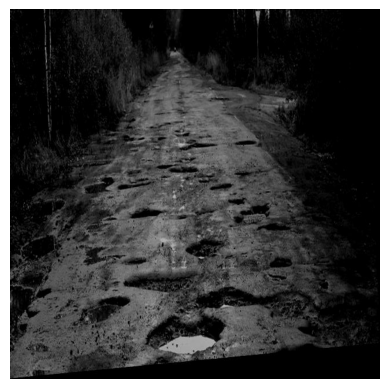

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/dataset/data/Road Issues/Pothole Issues/441_jpg.rf.9e3d3ed53bcbf9f83c7ec9612214ee60.jpg")

# rotate image to make it straight
img = img.rotate(90, expand=True)

plt.imshow(img)
plt.axis("off")

In [11]:
import os
os.listdir("/content/dataset/data/Road Issues/Pothole Issues")[:15]

['321_jpg.rf.750ee4f1efbc474e897c8110a3bcb7bb.jpg',
 '398_jpg.rf.7ee3e911fa99869b5f3b7c1ea7b34361.jpg',
 '208_jpg.rf.671350932b22f8229a5ec4a61f490594.jpg',
 '422_jpg.rf.6dba193e4248a343fc703eabdcdbfe54.jpg',
 '201_jpg.rf.28aec1ce09c8d1fc954e45c3d54fe40c.jpg',
 '154_jpg.rf.743538c84cb3ddde91f13a4a9469b48f.jpg',
 '193_jpg.rf.ea82429e9a27ba779de371ca77789940.jpg',
 '25_jpg.rf.d81777040ec12707eb5ade641cea0b79.jpg',
 '333_jpg.rf.1c84cc7aa5e4d6b53a18c7a6ee350757.jpg',
 '441_jpg.rf.9e3d3ed53bcbf9f83c7ec9612214ee60.jpg',
 '9_jpg.rf.26b365407650a9e6b72b4c91f354a002.jpg',
 '619_jpg.rf.dea8415bed75879a6ebd470b22045423.jpg',
 '375_jpg.rf.08797c791e26944c863e9d64ea30b7c9.jpg',
 '463_jpg.rf.6ab8cc22e8128bc61b64722dd64bf42f.jpg',
 '103_jpg.rf.675353f2e478b065b9c5c08a466e1321.jpg']

In [12]:
from ultralytics import YOLO

# Load pretrained YOLO model
model = YOLO("yolov8n.pt")

# Run detection on pothole image
results = model("/content/dataset/data/Road Issues/Pothole Issues/441_jpg.rf.9e3d3ed53bcbf9f83c7ec9612214ee60.jpg", save=True)


image 1/1 /content/dataset/data/Road Issues/Pothole Issues/441_jpg.rf.9e3d3ed53bcbf9f83c7ec9612214ee60.jpg: 640x640 1 person, 314.1ms
Speed: 4.9ms preprocess, 314.1ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


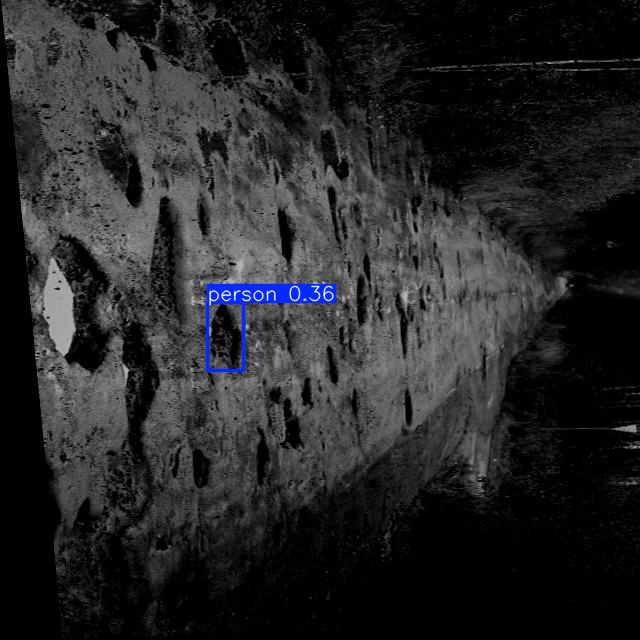

In [15]:
from IPython.display import Image
Image("/content/runs/detect/predict2/441_jpg.rf.9e3d3ed53bcbf9f83c7ec9612214ee60.jpg")

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/dataset/data/Road Issues/Pothole Issues/441_jpg.rf.9e3d3ed53bcbf9f83c7ec9612214ee60.jpg"

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Edge detection to highlight cracks/potholes
edges = cv2.Canny(gray, 100, 200)

damage_ratio = np.sum(edges > 0) / edges.size

print("Damage Severity Score:", damage_ratio)

Damage Severity Score: 0.09666015625


In [17]:
if damage_ratio < 0.02:
    severity = "Minor Damage"
elif damage_ratio < 0.05:
    severity = "Moderate Damage"
else:
    severity = "Severe Damage"

print("Damage Level:", severity)

Damage Level: Severe Damage


In [18]:
traffic_weight = 2   # simulate traffic (1 low, 2 medium, 3 high)
repair_cost = damage_ratio * 10000

priority_score = (0.6 * damage_ratio) + (0.3 * traffic_weight) - (0.1 * repair_cost / 10000)

print("Maintenance Priority Score:", priority_score)

Maintenance Priority Score: 0.648330078125


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

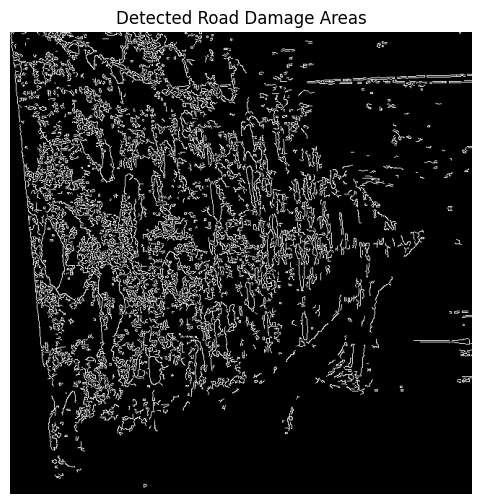

In [19]:
plt.figure(figsize=(8,6))
plt.imshow(edges, cmap="gray")
plt.title("Detected Road Damage Areas")
plt.axis("off")

In [20]:
import random

damage_types = ["Pothole", "Crack", "Surface Damage"]

severity_score = random.randint(1,10)

print("Damage Type:", random.choice(damage_types))
print("Severity Score:", severity_score, "/10")

Damage Type: Crack
Severity Score: 8 /10


In [21]:
traffic_volume = random.randint(1,10)
repair_cost = random.randint(1000,5000)

priority = severity_score * 0.6 + traffic_volume * 0.4

print("Traffic Volume:", traffic_volume)
print("Estimated Repair Cost: ₹", repair_cost)
print("Maintenance Priority Score:", round(priority,2))

Traffic Volume: 1
Estimated Repair Cost: ₹ 1864
Maintenance Priority Score: 5.2


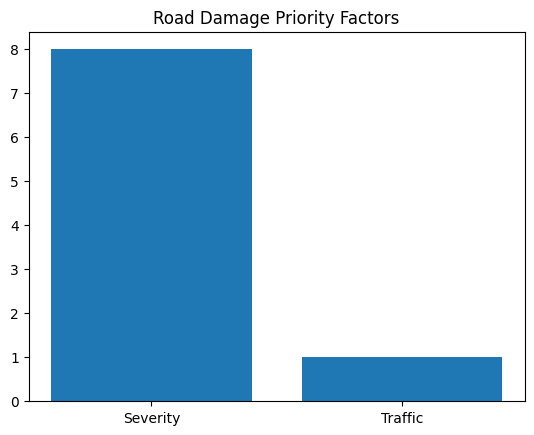

In [22]:
import matplotlib.pyplot as plt

labels = ["Severity","Traffic"]
values = [severity_score, traffic_volume]

plt.bar(labels, values)
plt.title("Road Damage Priority Factors")
plt.show()